In [24]:
import pandas as pd
from pathlib import Path
import pyarrow

# Update this path to your sleep-scored parquet file
parquet_path = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet")

sleep_df = pd.read_parquet(parquet_path)

print(f"Loaded {parquet_path}")
print(f"Rows: {len(sleep_df):,} | Columns: {sleep_df.shape[1]}")
sleep_df.head()

Loaded /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet
Rows: 256,240 | Columns: 10


,time_s,label,label_model,label_output,segment_id,kind,prob_wake,prob_nrem,prob_rem,prob_undef
0,0.0,0,1,0,0,signal,1.0,2.526451e-11,9.689391e-19,0.0
1,1.0,0,1,0,0,signal,1.0,1.835255e-09,1.988701e-22,0.0
2,2.0,0,1,0,0,signal,1.0,7.323096e-12,3.310262e-28,0.0
3,3.0,0,1,0,0,signal,1.0,1.391053e-13,2.144903e-35,0.0
4,4.0,0,1,0,0,signal,1.0,1.085064e-08,4.010148e-21,0.0


In [25]:
import mne
fif_path = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif")
raw = mne.io.read_raw_fif(fif_path, preload=False, verbose="ERROR")

print(f"Loaded .fif: {fif_path}")
print(raw)

Loaded .fif: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif
<Raw | sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif, 3 x 32798720 (256240.0 s), ~8 KiB, data not loaded>


In [26]:
# Load the artifact decisions generated for this recording.
artifact_parquet_path = parquet_path.with_name(
    f"{parquet_path.stem.replace('somnotate_predictions', '').rstrip('_-')}_artifact_epochs.parquet"
)
if not artifact_parquet_path.is_file():
    raise FileNotFoundError(f"Artifact parquet not found: {artifact_parquet_path}")

artifact_df = pd.read_parquet(artifact_parquet_path)
required_artifact_columns = {"epoch_id", "artifact"}
missing_artifact_columns = required_artifact_columns.difference(artifact_df.columns)
if missing_artifact_columns:
    raise ValueError(f"Artifact parquet is missing columns: {sorted(missing_artifact_columns)}")
if not pd.api.types.is_bool_dtype(artifact_df["artifact"]):
    raise TypeError("The artifact column must contain boolean values.")

artifact_by_epoch = artifact_df.groupby("epoch_id")["artifact"].any()
artifact_epoch_ids = frozenset(artifact_by_epoch.index[artifact_by_epoch])
print(f"Loaded artifact decisions: {artifact_parquet_path}")
print(f"Artifact epochs to exclude: {len(artifact_epoch_ids):,} / {len(artifact_by_epoch):,}")

Loaded artifact decisions: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_artifact_epochs.parquet
Artifact epochs to exclude: 1,226 / 64,060


In [27]:
raw

<Raw | sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif, 3 x 32798720 (256240.0 s), ~8 KiB, data not loaded>

In [28]:
import numpy as np

# Compute non-overlapping 4-second delta power while retaining EEG/EMG channels.
if "aligned_raw" not in globals():
    eeg_emg_picks = mne.pick_types(raw.info, eeg=True, emg=True, exclude=[])
    if len(eeg_emg_picks) == 0:
        raise ValueError("The FIF file contains no channels typed as EEG or EMG.")
    aligned_raw = raw.copy().pick(eeg_emg_picks)
epoch_seconds = 4.0
sfreq = float(aligned_raw.info["sfreq"])
epoch_samples = int(round(epoch_seconds * sfreq))
n_epochs = aligned_raw.n_times // epoch_samples

scores = sleep_df[["time_s", "label"]].copy()
scores["epoch_id"] = np.floor(scores["time_s"] / epoch_seconds).astype("int64")
score_counts = scores.groupby("epoch_id").size()
complete_score_epochs = score_counts[score_counts == int(epoch_seconds)].index
epoch_labels = (
    scores[scores["epoch_id"].isin(complete_score_epochs)]
    .groupby("epoch_id")["label"]
    .agg(lambda values: values.mode().iloc[0])
)

# Welch settings give sufficient resolution around the 0.5--4 Hz delta band.
n_per_seg = min(epoch_samples, int(round(2 * sfreq)))
n_fft = 1 << (n_per_seg - 1).bit_length()
n_overlap = n_per_seg // 2
rows = []
chunk_epochs = 512
for first_epoch in range(0, n_epochs, chunk_epochs):
    last_epoch = min(first_epoch + chunk_epochs, n_epochs)
    start = first_epoch * epoch_samples
    stop = last_epoch * epoch_samples
    samples = aligned_raw.get_data(start=start, stop=stop)
    batch = samples.reshape(len(aligned_raw.ch_names), last_epoch - first_epoch, epoch_samples)
    batch = np.moveaxis(batch, 1, 0)  # epochs x channels x samples
    batch *= 1e6  # MNE stores EEG/EMG in volts; calculate PSD in microvolts.
    psd, frequencies = mne.time_frequency.psd_array_welch(
        batch, sfreq=sfreq, fmin=0.5, fmax=4.0,
        n_fft=n_fft, n_per_seg=n_per_seg, n_overlap=n_overlap, verbose=False,
    )
    delta_power = np.trapezoid(psd, frequencies, axis=-1)
    for offset, power in enumerate(delta_power):
        epoch_id = first_epoch + offset
        if epoch_id not in epoch_labels.index or epoch_id in artifact_epoch_ids:
            continue
        rows.append({
            "epoch_id": epoch_id,
            "time_from_recording_start_s": epoch_id * epoch_seconds,
            "label": epoch_labels.loc[epoch_id],
            **dict(zip(aligned_raw.ch_names, power)),
        })

delta_power_df = pd.DataFrame(rows)
print(f"Computed {len(delta_power_df):,} artifact-free complete 4-second epochs")
print(f"Excluded {len(artifact_epoch_ids):,} artifact epochs before analysis")
print(f"Channels: {aligned_raw.ch_names} (delta power in uV^2)")
delta_power_df.head()

Computed 62,834 artifact-free complete 4-second epochs
Excluded 1,226 artifact epochs before analysis
Channels: ['EEG1A-B', 'EEG2A-B', 'EMG'] (delta power in uV^2)


,epoch_id,time_from_recording_start_s,label,EEG1A-B,EEG2A-B,EMG
0,0,0.0,0,357.555702,178.146424,344.634640
1,1,4.0,0,287.798769,92.960343,306.224192
2,2,8.0,0,274.499950,147.469212,598.230672
3,3,12.0,0,376.668716,243.540739,851.605159
4,4,16.0,0,509.670132,94.761022,72.687353


In [29]:
power_cols = [c for c in delta_power_df.columns if c not in ["epoch_id", "time_from_recording_start_s", "label"]]

mean_delta_by_label = delta_power_df.groupby("label")[power_cols].mean()
print(mean_delta_by_label)

            EEG1A-B       EEG2A-B         EMG
label                                        
0        520.771293    177.219325  310.418581
1       1197.963848    340.290957    4.821283
2        464.793558    195.118647    3.376182
3      28240.384636  28218.752421  709.403778


In [30]:
# Count occurrences where label == 3 in the per-second scoring table
count_label3 = (sleep_df["label"] == 3).sum()
print(f"label == 3 appears {count_label3:,} times in sleep_df")

# Optional: same count in 4-second epoch table
count_label3_epochs = (delta_power_df["label"] == 3).sum()
print(f"label == 3 appears {count_label3_epochs:,} times in delta_power_df")

label == 3 appears 34 times in sleep_df
label == 3 appears 5 times in delta_power_df


<IPython.core.display.Javascript object>

matplotlib backend: notebook
Showing first 70 hours only.
Showing channel: EEG1A-B
Values above 20000 are hidden.


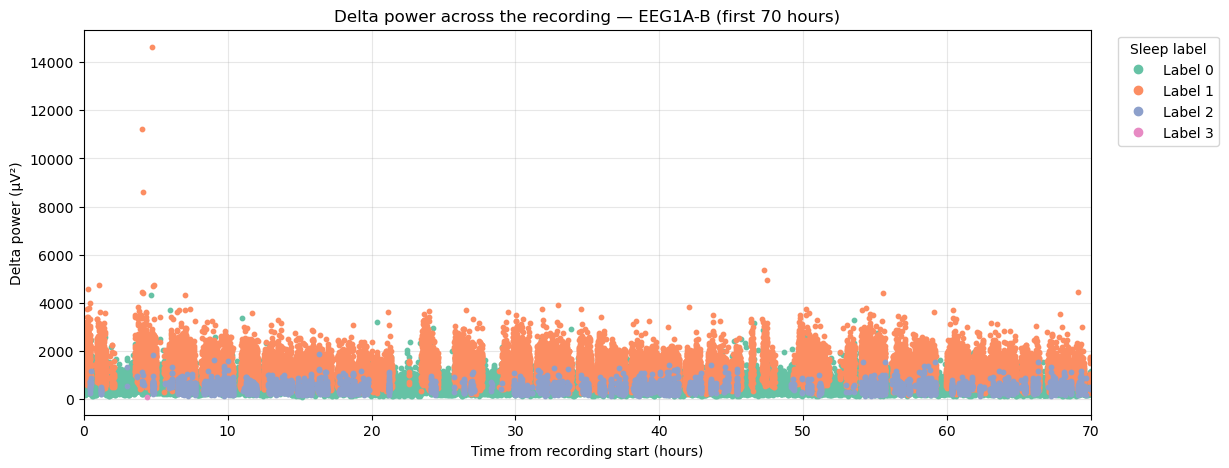

In [31]:
backend_used = None
for candidate in ("widget", "notebook", "inline"):
    try:
        get_ipython().run_line_magic("matplotlib", candidate)
        backend_used = candidate
        break
    except Exception:
        pass

import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.widgets import RadioButtons

if delta_power_df.empty:
    raise ValueError("delta_power_df is empty.")

max_delta_to_plot = 20000
max_hours_to_plot = 70
channel = power_cols[0]  # EEG channel 1

plot_df = delta_power_df.copy()
plot_df["time_h"] = plot_df["time_from_recording_start_s"] / 3600.0
plot_df = plot_df.loc[plot_df["time_h"] <= max_hours_to_plot].copy()

if plot_df.empty:
    raise ValueError(f"No data found in the first {max_hours_to_plot} hours.")

labels = sorted(plot_df["label"].dropna().unique())
cmap = plt.get_cmap("Set2")
label_colors = {label: cmap(i % cmap.N) for i, label in enumerate(labels)}

x = plot_df["time_h"].to_numpy()
label_array = plot_df["label"].to_numpy()
label_masks = {label: label_array == label for label in labels}

plt.close("all")
fig, ax = plt.subplots(figsize=(13, 5))

y = plot_df[channel].to_numpy()
valid = np.isfinite(y) & (y <= max_delta_to_plot)
y_plot = np.where(valid, y, np.nan)

scatter_artists = {}
for label in labels:
    mask = label_masks[label] & valid
    scatter_artists[label] = ax.scatter(
        x[mask],
        y[mask],
        s=10,
        color=label_colors[label],
        zorder=2,
        label=f"Label {label}",
    )

ax.set_title(f"Delta power across the recording — {channel} (first {max_hours_to_plot} hours)")
ax.set_xlabel("Time from recording start (hours)")
ax.set_ylabel("Delta power (µV²)")
ax.set_xlim(0, max_hours_to_plot)
ax.grid(True, alpha=0.3)

finite_y = y[valid]
if finite_y.size:
    ymin = finite_y.min()
    ymax = finite_y.max()
    pad = max((ymax - ymin) * 0.05, 1e-12)
    ax.set_ylim(ymin - pad, ymax + pad)

handles = [
    Line2D([0], [0], marker="o", linestyle="", color=label_colors[label], label=f"Label {label}", markersize=6)
    for label in labels
]
ax.legend(handles=handles, title="Sleep label", bbox_to_anchor=(1.02, 1), loc="upper left")

print(f"matplotlib backend: {backend_used}")
print(f"Showing first {max_hours_to_plot} hours only.")
print(f"Showing channel: {channel}")
print(f"Values above {max_delta_to_plot} are hidden.")

if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)


<IPython.core.display.Javascript object>

Computed 62,834 artifact-free complete 4-second epochs
Showing channel: EEG1A-B; ratios above 10 are hidden.


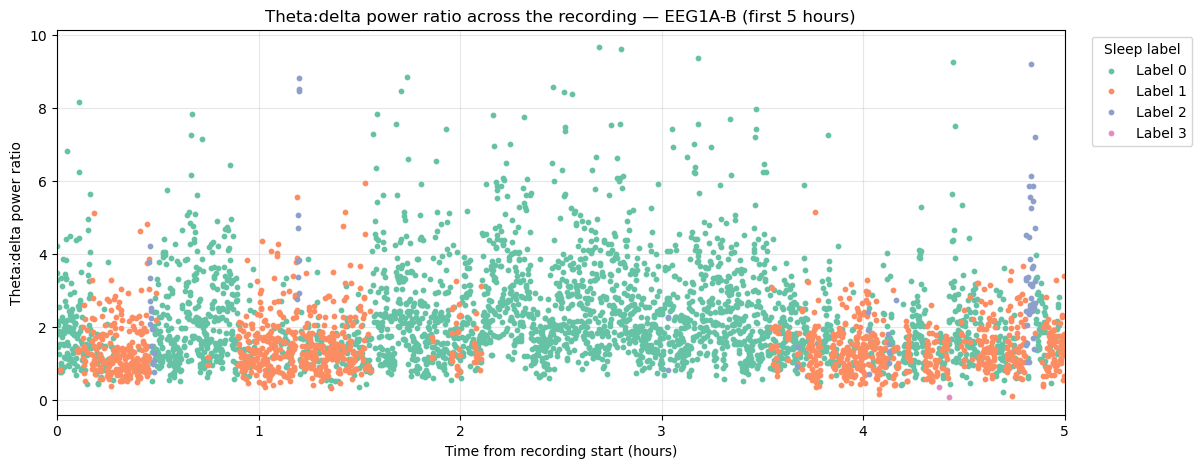

In [32]:
# Compute and plot the theta:delta power ratio in the same 4-second epochs.
theta_delta_rows = []
for first_epoch in range(0, n_epochs, chunk_epochs):
    last_epoch = min(first_epoch + chunk_epochs, n_epochs)
    start = first_epoch * epoch_samples
    stop = last_epoch * epoch_samples
    samples = aligned_raw.get_data(start=start, stop=stop)
    batch = samples.reshape(len(aligned_raw.ch_names), last_epoch - first_epoch, epoch_samples)
    batch = np.moveaxis(batch, 1, 0) * 1e6  # epochs x channels x samples, in microvolts
    psd, frequencies = mne.time_frequency.psd_array_welch(
        batch, sfreq=sfreq, fmin=0.5, fmax=10.0,
        n_fft=n_fft, n_per_seg=n_per_seg, n_overlap=n_overlap, verbose=False,
    )
    delta_mask = (frequencies >= 0.5) & (frequencies <= 4.0)
    theta_mask = (frequencies >= 4.0) & (frequencies <= 10.0)
    delta = np.trapezoid(psd[..., delta_mask], frequencies[delta_mask], axis=-1)
    theta = np.trapezoid(psd[..., theta_mask], frequencies[theta_mask], axis=-1)
    ratio = np.divide(theta, delta, out=np.full_like(theta, np.nan), where=delta > 0)

    for offset, channel_ratios in enumerate(ratio):
        epoch_id = first_epoch + offset
        if epoch_id not in epoch_labels.index or epoch_id in artifact_epoch_ids:
            continue
        theta_delta_rows.append({
            "epoch_id": epoch_id,
            "time_from_recording_start_s": epoch_id * epoch_seconds,
            "label": epoch_labels.loc[epoch_id],
            **dict(zip(aligned_raw.ch_names, channel_ratios)),
        })

theta_delta_ratio_df = pd.DataFrame(theta_delta_rows)
ratio_cols = [
    c for c in theta_delta_ratio_df.columns
    if c not in ["epoch_id", "time_from_recording_start_s", "label"]
]
if theta_delta_ratio_df.empty:
    raise ValueError("theta_delta_ratio_df is empty.")

max_ratio_to_plot = 10
max_hours_to_plot = 5
channel = ratio_cols[0]  # EEG channel 1
ratio_plot_df = theta_delta_ratio_df.copy()
ratio_plot_df["time_h"] = ratio_plot_df["time_from_recording_start_s"] / 3600.0
ratio_plot_df = ratio_plot_df.loc[ratio_plot_df["time_h"] <= max_hours_to_plot].copy()

labels = sorted(ratio_plot_df["label"].dropna().unique())
cmap = plt.get_cmap("Set2")
label_colors = {label: cmap(i % cmap.N) for i, label in enumerate(labels)}
x = ratio_plot_df["time_h"].to_numpy()
y = ratio_plot_df[channel].to_numpy()
label_array = ratio_plot_df["label"].to_numpy()
valid = np.isfinite(y) & (y <= max_ratio_to_plot)

fig, ax = plt.subplots(figsize=(13, 5))
for label in labels:
    mask = (label_array == label) & valid
    ax.scatter(x[mask], y[mask], s=10, color=label_colors[label], zorder=2, label=f"Label {label}")

ax.set_title(f"Theta:delta power ratio across the recording — {channel} (first {max_hours_to_plot} hours)")
ax.set_xlabel("Time from recording start (hours)")
ax.set_ylabel("Theta:delta power ratio")
ax.set_xlim(0, max_hours_to_plot)
ax.grid(True, alpha=0.3)
finite_y = y[valid]
if finite_y.size:
    ymin, ymax = finite_y.min(), finite_y.max()
    pad = max((ymax - ymin) * 0.05, 1e-12)
    ax.set_ylim(ymin - pad, ymax + pad)
ax.legend(title="Sleep label", bbox_to_anchor=(1.02, 1), loc="upper left")

print(f"Computed {len(theta_delta_ratio_df):,} artifact-free complete 4-second epochs")
print(f"Showing channel: {channel}; ratios above {max_ratio_to_plot} are hidden.")
if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)


,baseline_delta_power_uV2
EEG1A-B,1197.963848
EEG2A-B,340.290957


,EEG1A-B,EEG2A-B,n_nrem_epochs
hour,,,
0,1.856248,1.586344,312
1,0.931255,0.751311,371
2,-0.871797,-1.351252,16
3,1.453583,1.344548,206
4,1.418824,1.787845,400


<IPython.core.display.Javascript object>

NREM baseline uses 29,909 artifact-free epochs across 72 hours.
EEG channels included: ['EEG1A-B', 'EEG2A-B']; EMG channels excluded.
Recording start used for lighting: 2026-07-17T14:40:02+01:00


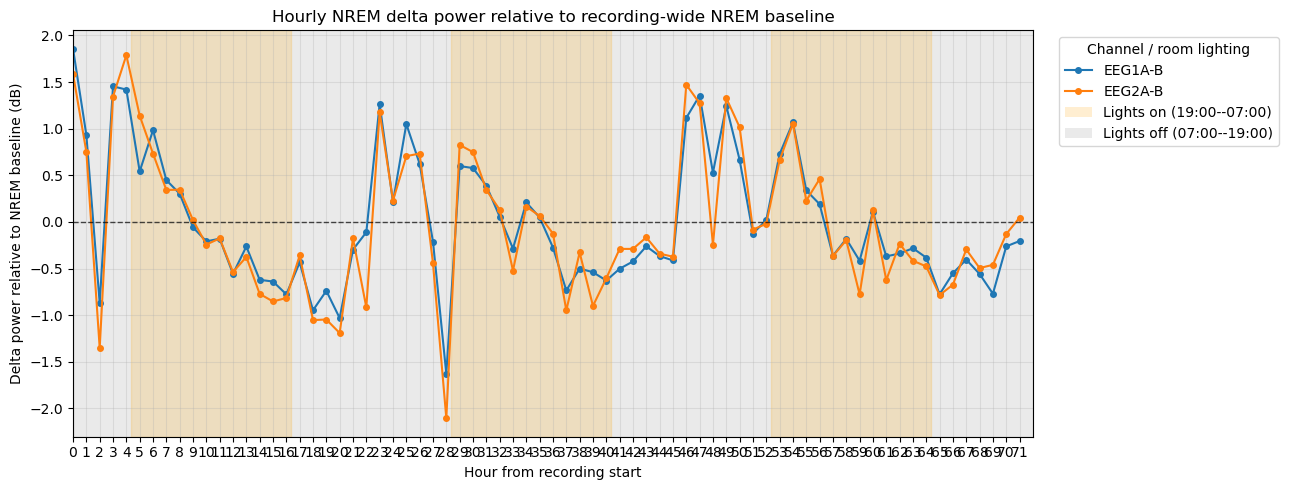

In [33]:
# Normalize hourly NREM delta power to the recording-wide NREM baseline.
# A value of 0 dB equals the baseline; positive/negative values are above/below it.
from matplotlib.patches import Patch
from zoneinfo import ZoneInfo

nrem_label = 1
room_timezone = ZoneInfo("Europe/London")
lights_on_hour = 19
lights_off_hour = 7
eeg_power_cols = [
    channel_name for channel_name, channel_type in zip(
        aligned_raw.ch_names, aligned_raw.get_channel_types()
    )
    if channel_type == "eeg" and channel_name in delta_power_df.columns
]
if not eeg_power_cols:
    raise ValueError("No EEG delta-power columns were found; EMG channels are excluded.")
nrem_delta = delta_power_df.loc[delta_power_df["label"] == nrem_label].copy()
if nrem_delta.empty:
    raise ValueError(f"No artifact-free epochs found for NREM label {nrem_label}.")

# Use the arithmetic mean of every artifact-free NREM epoch as the baseline, per channel.
nrem_baseline = nrem_delta[eeg_power_cols].mean()
if (nrem_baseline <= 0).any() or not np.isfinite(nrem_baseline).all():
    bad_channels = nrem_baseline.index[(nrem_baseline <= 0) | ~np.isfinite(nrem_baseline)].tolist()
    raise ValueError(f"Baseline power must be finite and positive; invalid channels: {bad_channels}")

nrem_delta["hour"] = (nrem_delta["time_from_recording_start_s"] // 3600).astype(int)
hourly_nrem_power = nrem_delta.groupby("hour")[eeg_power_cols].mean()
hourly_nrem_counts = nrem_delta.groupby("hour").size().rename("n_nrem_epochs")
hourly_nrem_db = 10.0 * np.log10(hourly_nrem_power.divide(nrem_baseline, axis="columns"))
hourly_nrem_db = hourly_nrem_db.join(hourly_nrem_counts)

display(nrem_baseline.rename("baseline_delta_power_uV2").to_frame())
display(hourly_nrem_db.head())

# Anchor the 19:00--07:00 light cycle to the recording's local acquisition time.
recording_start = raw.info.get("meas_date")
if recording_start is None:
    raise ValueError("raw.info['meas_date'] is required to align the room light/dark cycle.")
recording_start = pd.Timestamp(recording_start)
if recording_start.tzinfo is None:
    recording_start = recording_start.tz_localize(room_timezone)
else:
    recording_start = recording_start.tz_convert(room_timezone)
plot_end_h = float(hourly_nrem_db.index.max() + 1)
recording_end = recording_start + pd.Timedelta(hours=plot_end_h)

fig, ax = plt.subplots(figsize=(13, 5))
# Dark is the base shading; overlay the exact local-clock light intervals.
ax.axvspan(0, plot_end_h, color="grey", alpha=0.16, zorder=0)
calendar_days = pd.date_range(
    recording_start.normalize() - pd.Timedelta(days=1),
    recording_end.normalize() + pd.Timedelta(days=1),
    freq="D", tz=room_timezone,
)
for day in calendar_days:
    date_string = day.strftime("%Y-%m-%d")
    light_start = pd.Timestamp(f"{date_string} {lights_on_hour:02d}:00", tz=room_timezone)
    light_end = pd.Timestamp(f"{date_string} {lights_off_hour:02d}:00", tz=room_timezone)
    if light_end <= light_start:
        light_end += pd.DateOffset(days=1)
    span_start_h = max(0.0, (light_start - recording_start).total_seconds() / 3600.0)
    span_end_h = min(plot_end_h, (light_end - recording_start).total_seconds() / 3600.0)
    if span_start_h < span_end_h:
        ax.axvspan(span_start_h, span_end_h, color="orange", alpha=0.18, zorder=0)
for channel_name in eeg_power_cols:
    ax.plot(
        hourly_nrem_db.index, hourly_nrem_db[channel_name],
        marker="o", linewidth=1.5, markersize=4, label=channel_name,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("Hourly NREM delta power relative to recording-wide NREM baseline")
ax.set_xlabel("Hour from recording start")
ax.set_ylabel("Delta power relative to NREM baseline (dB)")
ax.set_xticks(hourly_nrem_db.index)
ax.set_xlim(0, plot_end_h)
ax.grid(True, alpha=0.3)
channel_handles, channel_labels = ax.get_legend_handles_labels()
lighting_handles = [
    Patch(facecolor="orange", alpha=0.18, label="Lights on (19:00--07:00)"),
    Patch(facecolor="grey", alpha=0.16, label="Lights off (07:00--19:00)"),
]
ax.legend(
    handles=channel_handles + lighting_handles,
    labels=channel_labels + [item.get_label() for item in lighting_handles],
    title="Channel / room lighting", bbox_to_anchor=(1.02, 1), loc="upper left",
)
fig.tight_layout()

print(f"NREM baseline uses {len(nrem_delta):,} artifact-free epochs across {len(hourly_nrem_db)} hours.")
print(f"EEG channels included: {eeg_power_cols}; EMG channels excluded.")
print(f"Recording start used for lighting: {recording_start.isoformat()}")
if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)


<IPython.core.display.Javascript object>

,hour,label,delta_power_uV2,theta_delta_ratio,emg_rms_uV
0,0,0,430.571993,1.716146,75.331899
1,0,1,1163.576981,1.472006,14.520956
2,0,2,428.075628,1.859446,11.662516
3,1,0,403.954784,1.682444,76.599952
4,1,1,944.510518,1.621266,14.811081


EEG channels averaged: ['EEG1A-B', 'EEG2A-B']
EMG channels averaged: ['EMG']


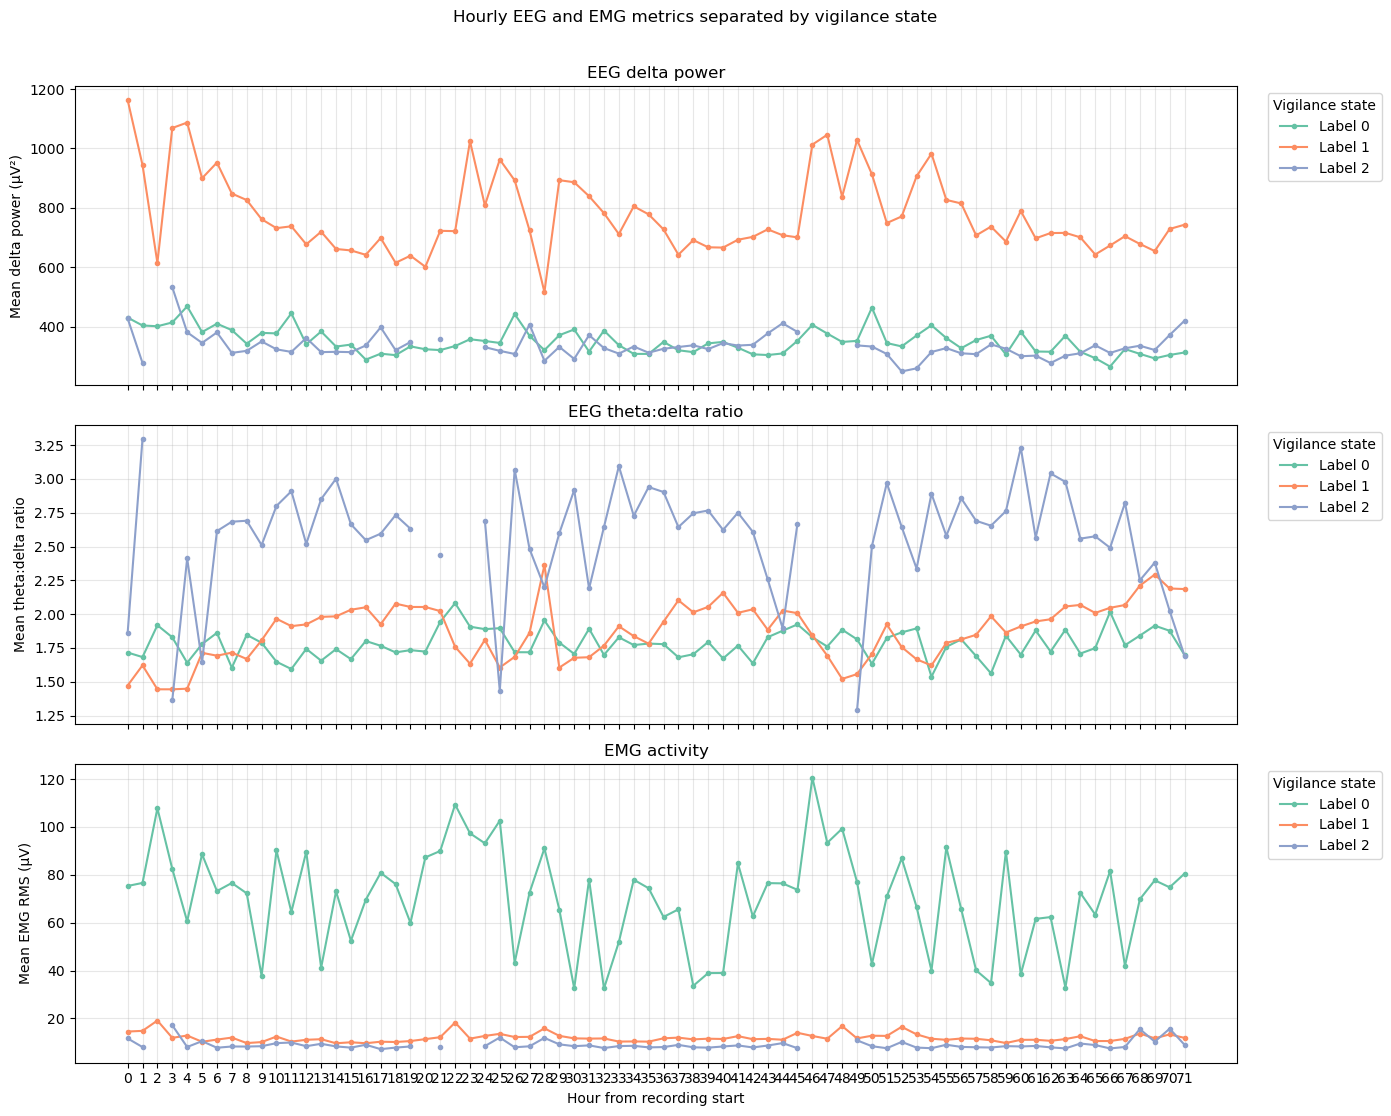

In [35]:
# Plot hourly EEG delta power, EEG theta:delta ratio, and EMG RMS by vigilance state.
eeg_metric_cols = [
    name for name, kind in zip(aligned_raw.ch_names, aligned_raw.get_channel_types())
    if kind == "eeg" and name in delta_power_df.columns and name in theta_delta_ratio_df.columns
]
emg_channels = [
    name for name, kind in zip(aligned_raw.ch_names, aligned_raw.get_channel_types())
    if kind == "emg"
]
if not eeg_metric_cols:
    raise ValueError("No EEG channels are shared by the delta and theta:delta tables.")
if not emg_channels:
    raise ValueError("No channels are typed as EMG in aligned_raw.")

# Calculate broadband EMG RMS (not EMG delta-band power) for each 4-second epoch.
emg_picks = [aligned_raw.ch_names.index(name) for name in emg_channels]
valid_epoch_ids = frozenset(delta_power_df["epoch_id"].astype(int))
emg_rows = []
for first_epoch in range(0, n_epochs, chunk_epochs):
    last_epoch = min(first_epoch + chunk_epochs, n_epochs)
    samples = aligned_raw.get_data(
        picks=emg_picks, start=first_epoch * epoch_samples, stop=last_epoch * epoch_samples
    )
    batch = samples.reshape(len(emg_channels), last_epoch - first_epoch, epoch_samples) * 1e6
    epoch_rms = np.sqrt(np.mean(np.square(batch), axis=-1)).T  # epochs x EMG channels, uV
    for offset, channel_rms in enumerate(epoch_rms):
        epoch_id = first_epoch + offset
        if epoch_id not in valid_epoch_ids:
            continue
        emg_rows.append({
            "epoch_id": epoch_id,
            "emg_rms_uV": float(np.mean(channel_rms)),
        })
emg_rms_df = pd.DataFrame(emg_rows)

# Average across EEG channels within each epoch, then summarize epochs by hour and state.
metric_epochs = delta_power_df[["epoch_id", "time_from_recording_start_s", "label"]].copy()
metric_epochs["delta_power_uV2"] = delta_power_df[eeg_metric_cols].mean(axis=1)
theta_delta_epoch = theta_delta_ratio_df.set_index("epoch_id")[eeg_metric_cols].mean(axis=1)
metric_epochs["theta_delta_ratio"] = metric_epochs["epoch_id"].map(theta_delta_epoch)
metric_epochs = metric_epochs.merge(emg_rms_df, on="epoch_id", how="inner")
metric_epochs["hour"] = (metric_epochs["time_from_recording_start_s"] // 3600).astype(int)
metric_names = ["delta_power_uV2", "theta_delta_ratio", "emg_rms_uV"]
hourly_metrics_by_state = (
    metric_epochs.groupby(["hour", "label"], as_index=False)[metric_names].mean()
)

excluded_plot_labels = {3}
states = sorted(
    state for state in hourly_metrics_by_state["label"].dropna().unique()
    if state not in excluded_plot_labels
)
state_cmap = plt.get_cmap("Set2")
state_colors = {state: state_cmap(i % state_cmap.N) for i, state in enumerate(states)}
metric_titles = [
    ("delta_power_uV2", "EEG delta power", "Mean delta power (µV²)"),
    ("theta_delta_ratio", "EEG theta:delta ratio", "Mean theta:delta ratio"),
    ("emg_rms_uV", "EMG activity", "Mean EMG RMS (µV)"),
]
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
all_hours = np.arange(
    hourly_metrics_by_state["hour"].min(), hourly_metrics_by_state["hour"].max() + 1
)
for ax, (metric, title, ylabel) in zip(axes, metric_titles):
    for state in states:
        state_values = (
            hourly_metrics_by_state.loc[hourly_metrics_by_state["label"] == state]
            .set_index("hour")[metric].reindex(all_hours)
        )
        ax.plot(
            all_hours, state_values, marker="o", markersize=3, linewidth=1.5,
            color=state_colors[state], label=f"Label {state}",
        )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Vigilance state", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[-1].set_xlabel("Hour from recording start")
axes[-1].set_xticks(all_hours)
fig.suptitle("Hourly EEG and EMG metrics separated by vigilance state", y=1.01)
fig.tight_layout()

display(hourly_metrics_by_state.head())
print(f"EEG channels averaged: {eeg_metric_cols}")
print(f"EMG channels averaged: {emg_channels}")
if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)
